# Learning the regularisation weight

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/torchsolve/blob/main/examples/03-differentiable_weight.ipynb)

The solve is differentiated implicitly rather than by unrolling: a gradient
arriving at the solution reaches the right-hand side, and anything the
operator closed over, through one more solve. Memory is therefore flat in the
iteration count, so a solve deep enough to converge costs a backward pass no
larger than a shallow one.

In [1]:
try:
    import torchsolve  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "torchsolve", "matplotlib"],
        check=True,
    )

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from torchsolve import conjugate_gradient

SIZE = 120


def problem():
    """A rough truth, a noisy measurement of it, and the penalty operator."""
    generator = torch.Generator().manual_seed(0)
    index = torch.arange(SIZE, dtype=torch.float64)
    truth = torch.sin(index / 9.0) + 0.4 * torch.sin(index / 2.5)
    measured = truth + 0.4 * torch.randn(SIZE, generator=generator, dtype=torch.float64)
    difference = torch.diff(torch.eye(SIZE, dtype=torch.float64), dim=0)
    return truth, measured, difference


truth, measured, difference = problem()

## Descending on the weight

`parameters=` is what makes the solve differentiable with respect to
something the operator closed over — here the weight itself, which appears
nowhere in the right-hand side.

In [3]:
log_weight = torch.tensor(-2.0, dtype=torch.float64, requires_grad=True)
optimiser = torch.optim.Adam([log_weight], lr=0.25)

history = []
for _ in range(60):
    optimiser.zero_grad()
    weight = log_weight.exp()
    estimate = conjugate_gradient(
        lambda vector, w=weight: vector + w * (difference.T @ (difference @ vector)),
        measured,
        max_iter=200,
        rtol=1e-12,
        parameters=[log_weight],
    ).solution
    loss = (estimate - truth).pow(2).mean()
    loss.backward()
    optimiser.step()
    history.append((weight.item(), loss.item()))

weights, losses = zip(*history, strict=True)
print(
    f"weight {weights[0]:.3f} -> {weights[-1]:.3f}, "
    f"loss {losses[0]:.4f} -> {losses[-1]:.4f}"
)

weight 0.135 -> 3.499, loss 0.1135 -> 0.0363


## What a sweep would have said

The check that matters: the gradient has to land where an exhaustive search
lands, or the implicit derivative is wrong.

In [4]:
grid = torch.logspace(-2, 2, 40, dtype=torch.float64)
swept = []
for candidate in grid:
    estimate = conjugate_gradient(
        lambda vector, c=candidate: vector + c * (difference.T @ (difference @ vector)),
        measured,
        max_iter=200,
        rtol=1e-12,
    ).solution
    swept.append((estimate - truth).pow(2).mean().item())
best = grid[torch.tensor(swept).argmin()].item()
print(f"a sweep of 40 solves puts the optimum at {best:.3f}")

a sweep of 40 solves puts the optimum at 2.894


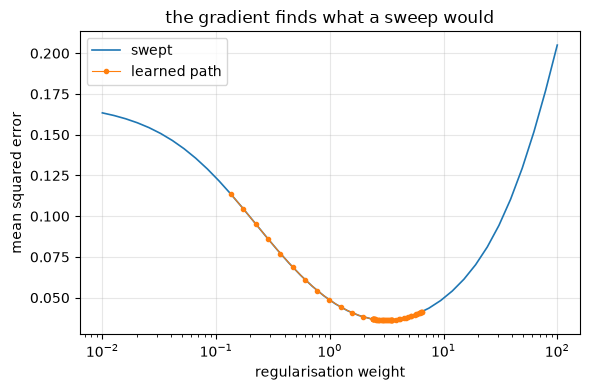

In [5]:
figure, axis = plt.subplots(figsize=(6, 4))
axis.semilogx(grid, swept, linewidth=1.2, label="swept")
axis.semilogx(weights, losses, "o-", markersize=3, linewidth=0.8, label="learned path")
axis.set_xlabel("regularisation weight")
axis.set_ylabel("mean squared error")
axis.set_title("the gradient finds what a sweep would")
axis.legend()
axis.grid(alpha=0.3)
figure.tight_layout()

figures = Path("figures")
if figures.is_dir():
    figure.savefig(figures / "differentiable_weight.png", dpi=120)